# Example of using inpainting to compute matched-filters

This example demonstrates how we can use data we used for our premerger search and compute matched-filters where we use inpainting to deal with gaps.

* Because this is a premerger search we assume a gap at the end (in the example, 7 days before the signal mergers). While we do have data for that period, this is equivalent to padding the data with 7 days of 0s and then inpainting over those days. This then forms an alternative for our previous zero-latency filter.

In [1]:
import os
import requests
from matplotlib import pyplot as plt
import json
import copy

import pycbc.psd
import pycbc.types
from pycbc.strain.gate import gate_and_paint
from pycbc.filter import matched_filter

from utils import *

/mnt/lustre2/shared_conda/envs/garethcd/env_lisa_premerger/lib/python3.10/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


No CuPy
No CuPy or GPU PhenomHM module.
No CuPy or GPU response available.
No CuPy or GPU interpolation available.
Could not import fastgb. Please pip install fastgb


In [ ]:
data_length = 2592000
zeroed_length = 2**20
sample_rate = 0.2
flen = int(zeroed_length) // 2 + 1
delta_f = 1 / (2**20 * 5)
delta_t = 1 / sample_rate

days_before_merger = 7

In [ ]:
# Get the PSD:
local_psd_filename = f'../../datasets/model_AE_TDI1_SMOOTH_optimistic.txt.gz'


# Assume A & E PSDs are the same
psd = pycbc.psd.from_txt(
    local_psd_filename, flen, delta_f, delta_f, is_asd_file=False
)
psds_for_datagen = {}
psds_for_datagen['LISA_A'] = psd
psds_for_datagen['LISA_E'] = psd.copy()

invpsd = 1./psd # Used for inpainting
invpsd[0] = 0 # Cannot have a DC component


/mnt/lustre2/shared_conda/envs/garethcd/env_lisa_premerger/lib/python3.10/site-packages/pycbc/types/array.py:390: RuntimeWarning: divide by zero encountered in divide
  return self._data.__rtruediv__(other)


## Plot the PSD

Text(0, 0.5, 'Power Spectral Density')

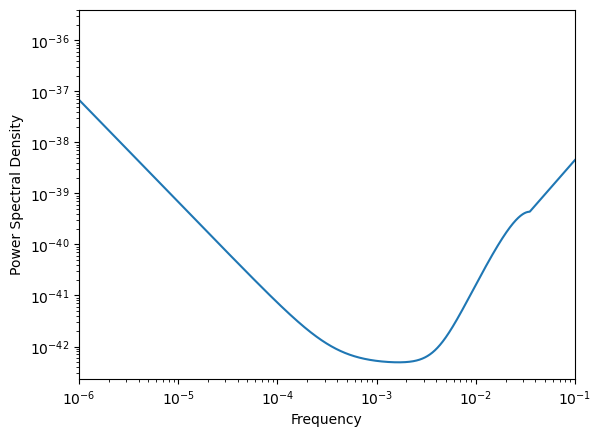

In [4]:
plt.loglog(psd.sample_frequencies, psd)
plt.xlim([1e-6, 0.1])
plt.xlabel('Frequency')
plt.ylabel('Power Spectral Density')

## Generate Data

In [ ]:
# The data we use here are from the lisa premerger paper
# and these are defined in this file:
local_injection_filename = '../../datasets/injections.json'

with open(local_injection_filename, 'r') as json_file:
    inj_definition_all = json.load(json_file)

inj_definition = inj_definition_all['0']
print(inj_definition)

{'mass1': 1000000.0, 'mass2': 1000000.0, 'spin1z': 0, 'spin2z': 0, 'additional_end_data': 1050, 'distance': 27658.011507544677, 'eclipticlongitude': 3.448296944257913, 'eclipticlatitude': 0.44491231446252155, 'inclination': 0.9238365050097769, 'polarization': 3.4236020095353483, 'coa_phase': 2.661901610522322, 'tc': 1931852406.9997194, 'fullband_snr': 1975.4707206749447}


In [ ]:

merger_time = inj_definition['tc']

In [ ]:

local_data_filename = f'../../datasets/signal_0.hdf'

data = pycbc.types.timeseries.load_timeseries(
        local_data_filename,
        group=f"/LISA_A",
)
data._delta_t = 5 # Apparently it is not exactly this in the file, causing issues.
data.resize(zeroed_length)

data_f = data.to_frequencyseries()

## Plot data

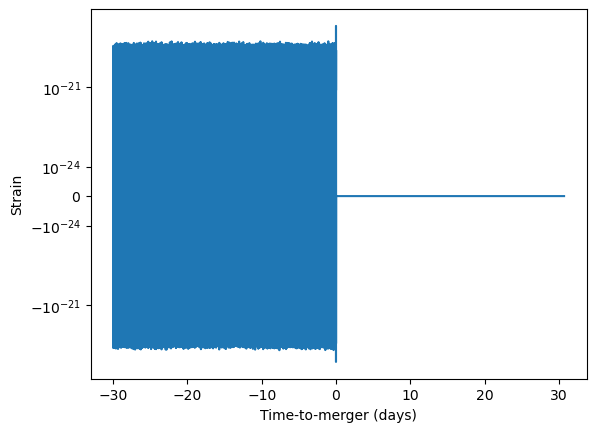

In [8]:
fig, ax = plt.subplots()

ax.plot((data.sample_times - merger_time)/86400, data)
ax.set_xlabel('Time-to-merger (days)')
ax.set_ylabel('Strain')
ax.set_yscale('symlog', linthresh=1e-24)

In [9]:
# Prepare the data (or datasets)


data_start = data.start_time
data_end = data.end_time
# Inpaint the end of the data, 7 days for this example
lindex = int((data_length - 86400 * days_before_merger) // delta_t)
rindex = int(data_length // delta_t)
data_inpainted = gate_and_paint(data, lindex, rindex, invpsd)

data_inpainted_fs = data_inpainted.to_frequencyseries()

## Plot the inpainted data

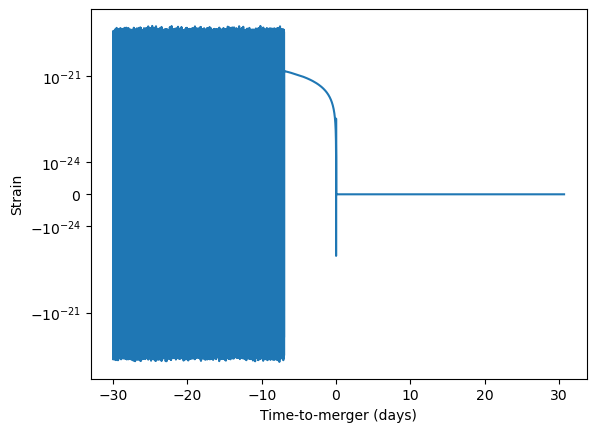

In [10]:
fig, ax = plt.subplots()

ax.plot((data_inpainted.sample_times - merger_time)/86400, data_inpainted)
ax.set_xlabel('Time-to-merger (days)')
ax.set_ylabel('Strain')
ax.set_yscale('symlog', linthresh=1e-24)

## Getting h - the waveform

In [11]:
# We know the signal exactly - it is in the data,

waveform_params = copy.copy(inj_definition)
waveform_params['tc'] = data_length
waveform_params['t_obs_start'] = data_length
waveform_params['approximant'] = 'BBHX_PhenomD'
waveform_params['f_lower'] = 1e-6
waveform_params['f_final'] = 1e-1
waveform_params['tdi'] = '1.5'
waveform_params['delta_f'] = delta_f
waveform_params['t_offset'] = 7365189.431698

waveform = generate_waveform_lisa_pre_merger(
    waveform_params,
    psd,
    inpaint=True
)['LISA_A']

waveform_ts = waveform.to_timeseries()

/mnt/lustre2/shared_conda/envs/garethcd/env_lisa_premerger/lib/python3.10/site-packages/BBHX_Phenom.py:287: RuntimeWarning: Input 'f_lower' is lower than the value calculated from 't_obs_start'.
  warn(err_msg, RuntimeWarning)


Text(0, 0.5, 'Strain')

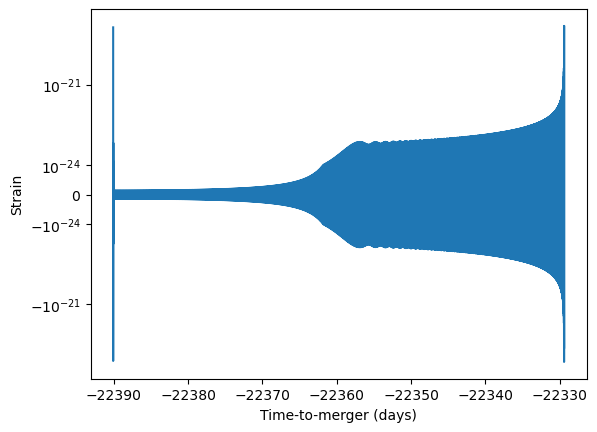

In [12]:
# Plot the signal
fig, ax = plt.subplots()
ax.plot((waveform_ts.sample_times - merger_time)/86400, waveform_ts)
ax.set_yscale('symlog', linthresh=1e-24)
ax.set_xlabel('Time-to-merger (days)')
ax.set_ylabel('Strain')

## Computing (h|s)

In [13]:
# This is straightforward,
# and that is the point of inpainting

snr = matched_filter(
    waveform,
    data_inpainted_fs,
    psd,
    sigmasq=1
)

ValueError: Length of template and data must match

In [ ]:
# Plot it
fig, ax = plt.subplots()
ax.plot((snr.sample_times - merger_time)/86400, snr)
ax.set_xlabel('Time-to-merger (days)')
ax.set_ylabel('SNR')

## Computing (h|h)

In [ ]:
# Now we want the (h|h), in order to 